# **Analisis Sentimen Pengguna Livin' by Mandiri pada Ulasan Google Play Store**

## **1. Inisiasi Pustaka**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import datetime as dt
import re
import string
import requests
import csv

from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from wordcloud import WordCloud
from io import StringIO

import nltk
import warnings
warnings.filterwarnings("ignore")

pd.options.mode.chained_assignment = None
seed = 0
np.random.seed(seed)

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from gensim.models import Word2Vec
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder

In [129]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, GRU, LSTM, Bidirectional

import joblib

## **2. Inisiasi Dataset**

In [3]:
livin_df = pd.read_csv('scraped_reviews.csv')
livin_df.head()

,review_id,user_name,score,date,text
0,c7ba2b43-f329-43f5-ae26-97000404b8c1,Pengguna Google,2,2025-03-22 23:01:26,setelah di-update malah nggak bisa berjalan se...
1,6c613682-7852-4c93-b423-0e7853d93519,Pengguna Google,1,2025-03-28 22:27:09,kenapa setelah dapat OTP lalu masukan OTP sist...
2,3def0af8-9d15-4dd7-8a53-826704f9657a,Pengguna Google,1,2025-04-12 12:18:36,"penanganan masalah lambat, tidak ada perkemban..."
3,9e09dd25-7695-483e-9881-7e7fbd57cad4,Pengguna Google,1,2025-04-05 01:05:19,sudah 2x ini saldo saya hilang atau terpotong ...
4,a6325579-20b3-45d9-83c7-731573a8233f,Pengguna Google,1,2025-03-13 18:40:06,Livin mandiri lagi kenapa ini ya???? Mau buka ...


In [4]:
livin_df.shape

(144000, 5)

Dataset terdiri dari 144.000 ulasan berbahasa Indonesia dengan 5 kolom.

In [5]:
livin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144000 entries, 0 to 143999
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   review_id  144000 non-null  object
 1   user_name  144000 non-null  object
 2   score      144000 non-null  int64 
 3   date       144000 non-null  object
 4   text       144000 non-null  object
dtypes: int64(1), object(4)
memory usage: 5.5+ MB


Dataset terdiri dari kolom *review id*, *username*, *score* (*rating*), *date*, dan *review text*. Dapat terlihat pula bahwa tidak terdapat nilai `null` pada dataset.

In [6]:
livin_df.duplicated().sum()

0

Terlihat pula tidak terdapat duplikasi data.

Mengambil sampel pada data sebesar 25% untuk mengurangi beban komputasi. Pengambilan sampel dilakukan dengan teknik *clustered sampling* berdasarkan *rating*. Hal ini digunakan untuk memastikan distribusi rating tetap sama.

In [7]:
df = livin_df.groupby('score').apply(lambda x: x.sample(frac=0.25, random_state=42)).reset_index(drop=True)
df.head()

,review_id,user_name,score,date,text
0,fbe93659-311b-4cd5-91a2-2130e2989ff7,Pengguna Google,1,2021-10-22 11:22:39,Tidak bisa registrasi di aplikasi ny padahal s...
1,2b2f0790-8448-4b69-8baa-0708145f50d2,Pengguna Google,1,2025-04-11 21:28:03,Tolong lh ya livin knp aku mau login ke akun s...
2,89f99492-5b5f-45fa-b373-7eab2db1547a,Pengguna Google,1,2023-01-05 11:26:31,Parah nih livin yg logo kuning...bagusan yg du...
3,cf0edbe1-368e-4edc-bd6b-3f9cf81cdfbe,Pengguna Google,1,2023-04-18 10:57:20,udh 3 hari nih aplikasi gak bisa di buka. ada ...
4,48727ca0-75ec-44e8-9567-181d45218d43,Pengguna Google,1,2024-07-27 21:52:58,Lagi eror mandiri


In [8]:
df.shape

(36001, 5)

Terdapat total 36.000 data.

## **3. Prapemrosesan Data**

Fungsi-fungsi prapemrosesan data teks sebagai berikut.

In [9]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka
 
    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text
 
def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text
 
def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text
 
def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text
 
def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
 
    # Memecah teks menjadi daftar kata
    words = text.split()
 
    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]
 
    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)
 
    return stemmed_text
 
def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

Penghapus kumpulan *slang words*:

In [10]:
url = 'https://raw.githubusercontent.com/louisowen6/NLP_bahasa_resources/master/combined_slang_words.txt'

def load_slangwords_from_url(url):
    response = requests.get(url)
    if response.status_code == 200:
        slangwords = {}
        
        lines = response.text.splitlines()
        for line in lines:
            parts = line.strip().split('=')
            if len(parts) == 2:
                slangwords[parts[0].lower()] = parts[1]
        return slangwords
    else:
        print(f"Gagal mengunduh kamus slang. Status code: {response.status_code}")
        return {}

slangwords = load_slangwords_from_url(url)

def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        clean_word = ''.join(e for e in word if e.isalnum())
        if clean_word.lower() in slangwords:
            fixed_words.append(slangwords[clean_word.lower()])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

Penyesuaian singkatan informal:

In [11]:
informal_abbreviations = {
    "ny": "nya",
    "yg": "yang",
    "knp": "kenapa",
    "lh": "lah",
    "udh": "sudah",
    "gk": "gak",
    "gt": "gitu",
    "bgt": "banget",
    "bgs": "bagus",
    "sm": "sama",
    "smpt": "sempat",
    "tdk": "tidak",
    "gtw": "gak tau",
    "dlu": "dulu",
    "dll": "dan lain-lain",
    "bgtu": "begitu",
    "dgn": "dengan",
    "dari": "dri",
    "tpi": "tapi",
    "brp": "berapa",
    "klo": "kalau",
    "skrg": "sekarang",
    "bgn": "bagian",
    "gmn": "gimana",
    "aj": "aja",
    "ak": "aku",
    "aq": "aku",
    "ampe": "sampai",
    "an": "anak",
    "b4": "sebelum",
    "br": "baru",
    "blm": "belum",
    "btw": "ngomong-ngomong",
    "cpe": "capek",
    "jgn": "jangan",
    "klu": "keluarga",
    "lbh": "lebih",
    "lg": "lagi",
    "mending": "lebih baik",
    "msh": "masih",
    "nnti": "nanti",
    "nmpk": "nampak",
    "slm": "salam",
    "sp": "seperti",
    "stlh": "setelah",
    "syg": "sayang",
    "tpi": "tapi",
    "tmpt": "tempat",
    "tw": "tahu",
    "xixixi": "tertawa",
    "bgtu": "begitu",
    "cm": "cuma",
    "cmiiw": "correct me if I'm wrong",
    "coz": "karena",
    "cpt": "cepat",
    "dsb": "dan sebagainya",
    "dpt": "dapat",
    "emg": "emang",
    "enak": "enakkan",
    "fyi": "for your information",
    "gpp": "gak apa-apa",
    "gr": "gede rasa",
    "gw": "gue",
    "hbd": "happy birthday",
    "hr": "hari",
    "hvs": "hard copy",
    "idk": "I don't know",
    "jgn": "jangan",
    "jwb": "jawab",
    "kbr": "kabar",
    "km": "kamu",
    "kmrn": "kemarin",
    "klo": "kalau",
    "ktp": "kartu tanda penduduk",
    "lbh": "lebih",
    "lgsg": "langsung",
    "mdh": "mudah-mudahan",
    "msh": "masih",
    "mnta": "minta",
    "ngak": "tidak",
    "nggak": "tidak",
    "ngomong": "bicara",
    "ngapain": "sedang apa",
    "ngambil": "mengambil",
    "nyesel": "menyesal",
    "or": "atau",
    "plg": "pulang",
    "pk": "penjahat kelamin",
    "qt": "kita",
    "rka": "rencana kerja anggaran",
    "romantis": "romantis",
    "saran": "sarannya",
    "selow": "santai",
    "smua": "semua",
    "smpt": "sempat",
    "sp": "seperti",
    "sr": "sore",
    "suk": "masuk",
    "tn": "terima kasih",
    "tp": "tapi",
    "tw": "tahu",
    "udh": "sudah",
    "yah": "ya",
    "yg": "yang",
    "yn": "yang lain",
    "zmn": "zaman",
    "gak": "tidak",
    "gitu": "begitu",
    "gimana": "bagaimana",
    "gmn": "bagaimana",
    "gpp": "tidak apa-apa",
    "hr": "hari",
    "km": "kamu",
    "knp": "kenapa",
    "kmrn": "kemarin",
    "krn": "karena",
    "msh": "masih",
    "msih": "masih",
    "nnti": "nanti",
    "nggak": "tidak",
    "sm": "dengan",
    "nih": "ini",
    "tau": "tahu",
    "aj": "saja",
    "sj": "saja",
    "aja": "saja",
    "bgus": "bagus",
    "bgt": "banget",
    "pls": "tolong",
    "plis": "tolong",
    "please": "tolong",
    'eror': 'error',
    'dri': 'dari',
    'bagu': 'bagus',
    'sy': 'saya',
    'sya': 'saya',
    'kalo': 'kalau',
    'jd': 'jadi',
    'tf': 'transfer',
    'g': 'tidak',
    'jd': 'jadi',
    'knpa': 'kenapa',
    'trus': 'terus',
    'baguss': 'bagus',
    'bagusss': 'bagus',
    'udah': 'sudah',
    'karna': 'karena'
}


def fix_informal_abbreviations(text):
    words = text.split()
    fixed_words = []

    for word in words:
        clean_word = word.lower()
        if clean_word in informal_abbreviations:
            fixed_words.append(informal_abbreviations[clean_word])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text

In [12]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
df['text_clean'] = df['text'].apply(cleaningText)
 
# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
df['text_casefoldingText'] = df['text_clean'].apply(casefoldingText)
 
# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
df['text_slangwords'] = df['text_casefoldingText'].apply(fix_slangwords)

# Mengganti singkatan informal dengan kata-kata standar dan menyimpannya di 'text_informalwords'
df['text_informalwords'] = df['text_slangwords'].apply(fix_informal_abbreviations)
 
# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
df['text_tokenizingText'] = df['text_informalwords'].apply(tokenizingText)
 
# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
df['text_stopword'] = df['text_tokenizingText'].apply(filteringText)
 
# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
df['text_akhir'] = df['text_stopword'].apply(toSentence)

Cek data:

In [13]:
df.head()

,review_id,user_name,score,date,text,text_clean,text_casefoldingText,text_slangwords,text_informalwords,text_tokenizingText,text_stopword,text_akhir
0,fbe93659-311b-4cd5-91a2-2130e2989ff7,Pengguna Google,1,2021-10-22 11:22:39,Tidak bisa registrasi di aplikasi ny padahal s...,Tidak bisa registrasi di aplikasi ny padahal s...,tidak bisa registrasi di aplikasi ny padahal s...,tidak bisa registrasi di aplikasi ny padahal s...,tidak bisa registrasi di aplikasi nya padahal ...,"[tidak, bisa, registrasi, di, aplikasi, nya, p...","[registrasi, aplikasi, datanya, salah, kasih]",registrasi aplikasi datanya salah kasih
1,2b2f0790-8448-4b69-8baa-0708145f50d2,Pengguna Google,1,2025-04-11 21:28:03,Tolong lh ya livin knp aku mau login ke akun s...,Tolong lh ya livin knp aku mau login ke akun s...,tolong lh ya livin knp aku mau login ke akun s...,tolong lh ya livin knp aku mau login ke akun s...,tolong lah ya livin kenapa aku mau login ke ak...,"[tolong, lah, ya, livin, kenapa, aku, mau, log...","[tolong, livin, login, akun, dipencet, plese, ...",tolong livin login akun dipencet plese diginii...
2,89f99492-5b5f-45fa-b373-7eab2db1547a,Pengguna Google,1,2023-01-05 11:26:31,Parah nih livin yg logo kuning...bagusan yg du...,Parah nih livin yg logo kuningbagusan yg dulu ...,parah nih livin yg logo kuningbagusan yg dulu ...,parah nih livin yg logo kuningbagusan yg dulu ...,parah ini livin yang logo kuningbagusan yang d...,"[parah, ini, livin, yang, logo, kuningbagusan,...","[parah, livin, logo, kuningbagusan, sebelsetia...",parah livin logo kuningbagusan sebelsetiap buk...
3,cf0edbe1-368e-4edc-bd6b-3f9cf81cdfbe,Pengguna Google,1,2023-04-18 10:57:20,udh 3 hari nih aplikasi gak bisa di buka. ada ...,udh hari nih aplikasi gak bisa di buka ada yg...,udh hari nih aplikasi gak bisa di buka ada yg...,udh hari nih aplikasi gak bisa di buka ada yg ...,sudah hari ini aplikasi tidak bisa di buka ada...,"[sudah, hari, ini, aplikasi, tidak, bisa, di, ...","[aplikasi, buka, mengalami, bank, plat, merah,...",aplikasi buka mengalami bank plat merah jelek ...
4,48727ca0-75ec-44e8-9567-181d45218d43,Pengguna Google,1,2024-07-27 21:52:58,Lagi eror mandiri,Lagi eror mandiri,lagi eror mandiri,lagi eror mandiri,lagi error mandiri,"[lagi, error, mandiri]","[error, mandiri]",error mandiri


Cek text akhir yang kosong karena hanya berisi emoji atau *stopwords*.

In [14]:
df[df['text_akhir'] == ''].shape

(524, 12)

Terdapat 524 data yang kosong karena ulasan hanya berisi emoji dan/atau *stopwords*. Data tersebut akan dihapuskan.

In [15]:
df = df[df['text_akhir'] != '']
df.reset_index(drop=True, inplace=True)

## **4. Pelabelan Data**

In [16]:
lexicon_positive = dict() 
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
 
if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
 
    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")
 
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()
 
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
 
if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
 
    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [17]:
def sentiment_analysis_lexicon_indonesia(text):
    score = 0
    
    # Inisialisasi skor sentimen ke 0
    for word in text:

        # Mengulangi setiap kata dalam tekt
        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen
 
    for word in text:
        
        # Mengulangi setiap kata dalam teks (sekali lagi)
        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen
 
    polarity=''
    # Inisialisasi variabel polaritas
 
    if (score > 0):
        polarity = 'positive'
        # Jika skor sentimen lebih besar atau sama dengan 0, maka polaritas adalah positif
    elif (score < 0):
        polarity = 'negative'
        # Jika skor sentimen kurang dari 0, maka polaritas adalah negatif
    else:
        polarity = 'neutral'
        # Ini adalah bagian yang bisa digunakan untuk menentukan polaritas netral jika diperlukan
 
    return score, polarity
    # Mengembalikan skor sentimen dan polaritas teks

In [18]:
results = df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
df['polarity_score'] = results[0]
df['polarity'] = results[1]
print(df['polarity'].value_counts())

polarity
negative    15789
positive    12199
neutral      7489
Name: count, dtype: int64


Validasi label berdasarkan *rating*:

In [19]:
df.head()

,review_id,user_name,score,date,text,text_clean,text_casefoldingText,text_slangwords,text_informalwords,text_tokenizingText,text_stopword,text_akhir,polarity_score,polarity
0,fbe93659-311b-4cd5-91a2-2130e2989ff7,Pengguna Google,1,2021-10-22 11:22:39,Tidak bisa registrasi di aplikasi ny padahal s...,Tidak bisa registrasi di aplikasi ny padahal s...,tidak bisa registrasi di aplikasi ny padahal s...,tidak bisa registrasi di aplikasi ny padahal s...,tidak bisa registrasi di aplikasi nya padahal ...,"[tidak, bisa, registrasi, di, aplikasi, nya, p...","[registrasi, aplikasi, datanya, salah, kasih]",registrasi aplikasi datanya salah kasih,-7,negative
1,2b2f0790-8448-4b69-8baa-0708145f50d2,Pengguna Google,1,2025-04-11 21:28:03,Tolong lh ya livin knp aku mau login ke akun s...,Tolong lh ya livin knp aku mau login ke akun s...,tolong lh ya livin knp aku mau login ke akun s...,tolong lh ya livin knp aku mau login ke akun s...,tolong lah ya livin kenapa aku mau login ke ak...,"[tolong, lah, ya, livin, kenapa, aku, mau, log...","[tolong, livin, login, akun, dipencet, plese, ...",tolong livin login akun dipencet plese diginii...,0,neutral
2,89f99492-5b5f-45fa-b373-7eab2db1547a,Pengguna Google,1,2023-01-05 11:26:31,Parah nih livin yg logo kuning...bagusan yg du...,Parah nih livin yg logo kuningbagusan yg dulu ...,parah nih livin yg logo kuningbagusan yg dulu ...,parah nih livin yg logo kuningbagusan yg dulu ...,parah ini livin yang logo kuningbagusan yang d...,"[parah, ini, livin, yang, logo, kuningbagusan,...","[parah, livin, logo, kuningbagusan, sebelsetia...",parah livin logo kuningbagusan sebelsetiap buk...,-7,negative
3,cf0edbe1-368e-4edc-bd6b-3f9cf81cdfbe,Pengguna Google,1,2023-04-18 10:57:20,udh 3 hari nih aplikasi gak bisa di buka. ada ...,udh hari nih aplikasi gak bisa di buka ada yg...,udh hari nih aplikasi gak bisa di buka ada yg...,udh hari nih aplikasi gak bisa di buka ada yg ...,sudah hari ini aplikasi tidak bisa di buka ada...,"[sudah, hari, ini, aplikasi, tidak, bisa, di, ...","[aplikasi, buka, mengalami, bank, plat, merah,...",aplikasi buka mengalami bank plat merah jelek ...,-11,negative
4,48727ca0-75ec-44e8-9567-181d45218d43,Pengguna Google,1,2024-07-27 21:52:58,Lagi eror mandiri,Lagi eror mandiri,lagi eror mandiri,lagi eror mandiri,lagi error mandiri,"[lagi, error, mandiri]","[error, mandiri]",error mandiri,-8,negative


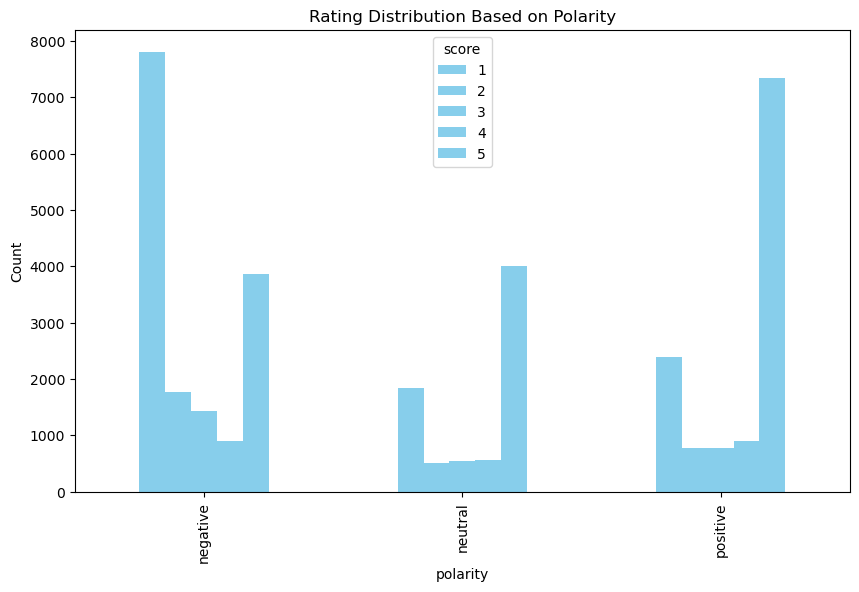

In [20]:
plt.figure(figsize=(10, 6))
plt.title('Rating Distribution Based on Polarity')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y')

# Grouping the data by 'polarity' and 'score', then counting occurrences
rating_polarity_counts = df.groupby('polarity')['score'].value_counts().unstack().fillna(0)

# Plotting the bar plot for each polarity
rating_polarity_counts.plot(kind='bar', stacked=False, color='skyblue', ax=plt.gca())

plt.show()

Visualisasi *wordcloud* pada setiap sentimen:

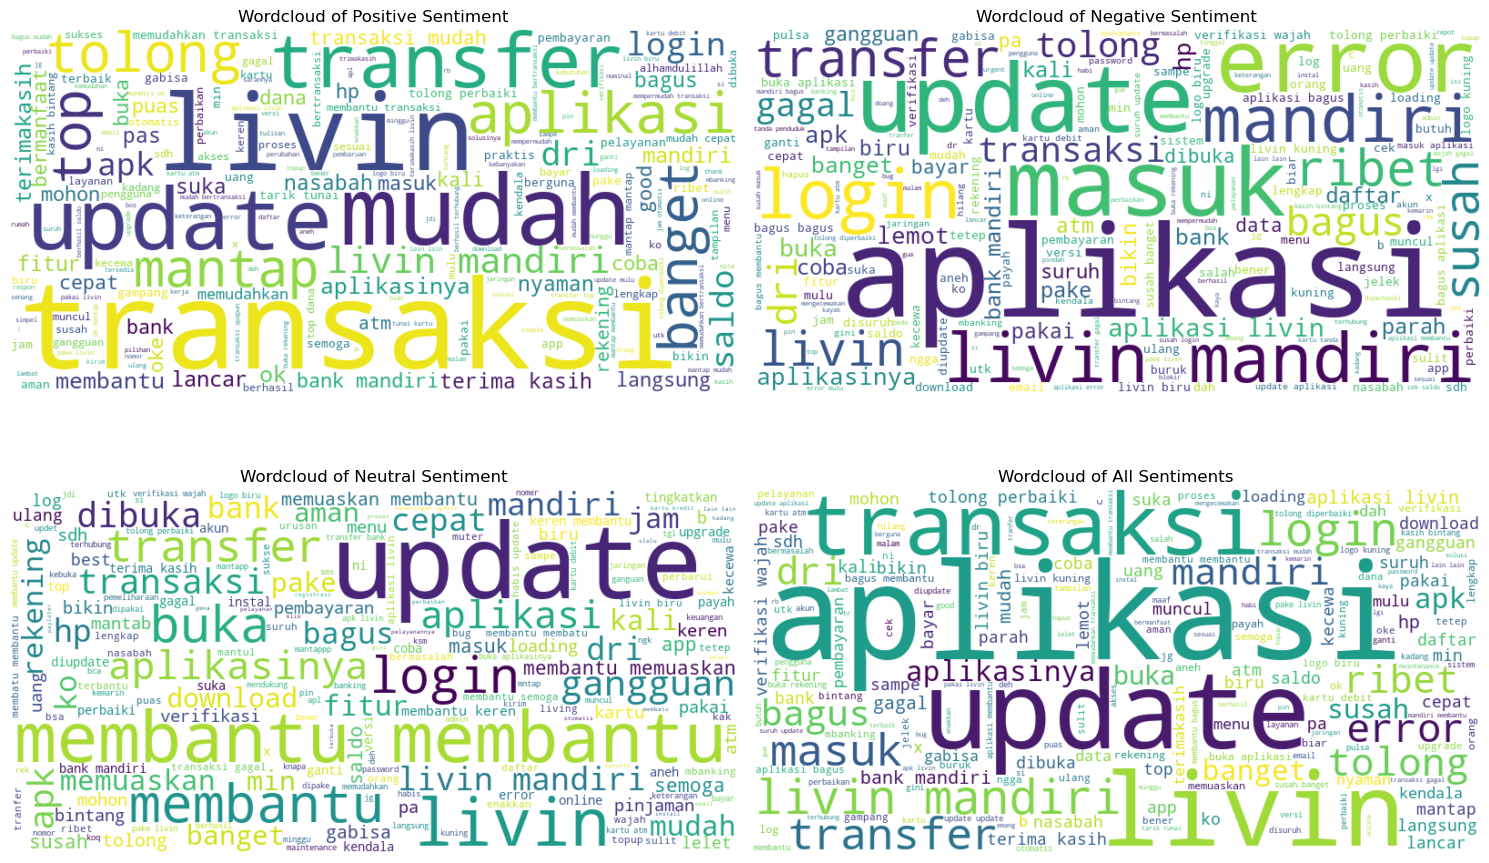

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Wordcloud for Positive Sentiment
axes[0, 0].set_title('Wordcloud of Positive Sentiment')
axes[0, 0].axis('off')
wordcloud_positive = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df[df['polarity'] == 'positive']['text_akhir']))
axes[0, 0].imshow(wordcloud_positive, interpolation='bilinear')

# Wordcloud for Negative Sentiment
axes[0, 1].set_title('Wordcloud of Negative Sentiment')
axes[0, 1].axis('off')
wordcloud_negative = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df[df['polarity'] == 'negative']['text_akhir']))
axes[0, 1].imshow(wordcloud_negative, interpolation='bilinear')

# Wordcloud for Neutral Sentiment
axes[1, 0].set_title('Wordcloud of Neutral Sentiment')
axes[1, 0].axis('off')
wordcloud_neutral = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df[df['polarity'] == 'neutral']['text_akhir']))
axes[1, 0].imshow(wordcloud_neutral, interpolation='bilinear')

# Wordcloud for All Sentiments
axes[1, 1].set_title('Wordcloud of All Sentiments')
axes[1, 1].axis('off')
wordcloud_all = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df['text_akhir']))
axes[1, 1].imshow(wordcloud_all, interpolation='bilinear')

plt.tight_layout()
plt.show()

## **5. Ekstraksi Fitur dan Pemodelan**

Inisiasi class Word2Vec:

In [22]:
class Word2VecTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, vector_size=100, window=5, min_count=1):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.model = None

    def fit(self, X, y=None):
        # Membuat model Word2Vec
        self.model = Word2Vec(X, vector_size=self.vector_size, window=self.window, min_count=self.min_count, workers=4)
        return self

    def transform(self, X):
        # Mengubah teks menjadi representasi vektor
        return np.array([
            np.mean([self.model.wv[word] for word in text if word in self.model.wv] or [np.zeros(self.vector_size)], axis=0)
            for text in X
        ])

Pembuatan *pipeline* untuk pemilihan ekstraksi fitur, pemecahan menjadi data latih dan uji, serta pembentukan model pada scikit learn sekaligus.

In [87]:
def create_pipeline(model_name, vectorizer_name, test_size=0.2, random_state=42):
    '''
    Fungsi untuk membuat pipeline dengan model dan vectorizer yang dipilih.
    Args:
        model_name (str): Nama model yang ingin digunakan ('svm', 'nb', 'lr', 'rf', 'dt').
        vectorizer_name (str): Nama vectorizer yang ingin digunakan ('tfidf', 'count', 'word2vec').
        test_size (float): Proporsi data untuk pengujian.
        random_state (int): Seed untuk pembagian data.
    Returns:
        report_train: Classification report pada data latih.
        report_test: Classification report pada data uji.
        pipeline (Pipeline): Pipeline yang telah dilatih.
    '''
    if vectorizer_name == 'tfidf':
        vectorizer = TfidfVectorizer(max_features=None)
    elif vectorizer_name == 'count':
        vectorizer = CountVectorizer(max_features=None)
    elif vectorizer_name == 'word2vec':
        vectorizer = Word2VecTransformer()

    if model_name == 'svm':
        model = SVC(kernel='linear')
    elif model_name == 'nb':
        model = BernoulliNB()
    elif model_name == 'lr':
        model = LogisticRegression()
    elif model_name == 'rf':
        model = RandomForestClassifier()
    elif model_name == 'dt':
        model = DecisionTreeClassifier()
    else:
        raise ValueError("Model not recognized. Choose from 'svm', 'nb', 'lr', 'rf', 'dt'.")

    # Buat pipeline
    pipeline = Pipeline([
        ('vectorizer', vectorizer),
        ('classifier', model)
    ])
    
    # Pembagian data latih dan uji
    X = df['text_akhir']
    y = df['polarity']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    # Melatih model
    pipeline.fit(X_train, y_train)
    report_train = classification_report(y_train, pipeline.predict(X_train))

    # Prediksi dan evaluasi akurasi
    y_pred = pipeline.predict(X_test)
    report_test = classification_report(y_test, y_pred)

    print(f"Model: {model_name}, Vectorizer: {vectorizer_name}, Test Size: {test_size}")
    print("Classification Report (Train):")
    print(report_train)
    print("Classification Report (Test):")
    print(report_test)
    acc_train = accuracy_score(y_train, pipeline.predict(X_train))
    acc_test = accuracy_score(y_test, y_pred)
    
    return report_train, report_test, pipeline, acc_train, acc_test

Pemodelan:

In [88]:
# Kombinasi 1: SVM dengan TF-IDF
report_train_1, report_test_1, pipeline_1, acc_train_1, acc_test_1 = create_pipeline('svm', 'tfidf')

Model: svm, Vectorizer: tfidf, Test Size: 0.2
Classification Report (Train):
              precision    recall  f1-score   support

    negative       0.96      0.99      0.98     12628
     neutral       0.97      0.90      0.93      5980
    positive       0.97      0.98      0.97      9773

    accuracy                           0.97     28381
   macro avg       0.97      0.96      0.96     28381
weighted avg       0.97      0.97      0.97     28381

Classification Report (Test):
              precision    recall  f1-score   support

    negative       0.93      0.96      0.94      3161
     neutral       0.90      0.85      0.87      1509
    positive       0.94      0.93      0.94      2426

    accuracy                           0.93      7096
   macro avg       0.92      0.91      0.92      7096
weighted avg       0.93      0.93      0.93      7096



In [89]:
# Kombinasi 2: Naive Bayes dengan Count Vectorizer
report_train_2, report_test_2, pipeline_2, acc_train_2, acc_test_2 = create_pipeline('nb', 'count')

Model: nb, Vectorizer: count, Test Size: 0.2
Classification Report (Train):
              precision    recall  f1-score   support

    negative       0.85      0.80      0.82     12628
     neutral       0.82      0.80      0.81      5980
    positive       0.78      0.86      0.82      9773

    accuracy                           0.82     28381
   macro avg       0.82      0.82      0.82     28381
weighted avg       0.82      0.82      0.82     28381

Classification Report (Test):
              precision    recall  f1-score   support

    negative       0.80      0.77      0.78      3161
     neutral       0.78      0.74      0.76      1509
    positive       0.72      0.79      0.75      2426

    accuracy                           0.77      7096
   macro avg       0.77      0.76      0.76      7096
weighted avg       0.77      0.77      0.77      7096



In [90]:
# Kombinasi 3: Logistic Regression dengan Word2Vec
report_train_3, report_test_3, pipeline_3, acc_train_3, acc_test_3 = create_pipeline('lr', 'word2vec')

Model: lr, Vectorizer: word2vec, Test Size: 0.2
Classification Report (Train):
              precision    recall  f1-score   support

    negative       0.71      0.83      0.77     12628
     neutral       0.69      0.53      0.60      5980
    positive       0.71      0.65      0.68      9773

    accuracy                           0.70     28381
   macro avg       0.70      0.67      0.68     28381
weighted avg       0.70      0.70      0.70     28381

Classification Report (Test):
              precision    recall  f1-score   support

    negative       0.70      0.83      0.76      3161
     neutral       0.72      0.50      0.59      1509
    positive       0.69      0.65      0.67      2426

    accuracy                           0.70      7096
   macro avg       0.70      0.66      0.67      7096
weighted avg       0.70      0.70      0.69      7096



In [91]:
# Kombinasi 4: Random Forest dengan TF-IDF
report_train_4, report_test_4, pipeline_4, acc_train_4, acc_test_4 = create_pipeline('rf', 'tfidf', test_size=0.3)

Model: rf, Vectorizer: tfidf, Test Size: 0.3
Classification Report (Train):
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00     11041
     neutral       1.00      1.00      1.00      5285
    positive       1.00      1.00      1.00      8507

    accuracy                           1.00     24833
   macro avg       1.00      1.00      1.00     24833
weighted avg       1.00      1.00      1.00     24833

Classification Report (Test):
              precision    recall  f1-score   support

    negative       0.85      0.94      0.89      4748
     neutral       0.88      0.85      0.87      2204
    positive       0.93      0.81      0.87      3692

    accuracy                           0.88     10644
   macro avg       0.88      0.87      0.87     10644
weighted avg       0.88      0.88      0.88     10644



In [92]:
# Kombinasi 5: Decision Tree dengan Count Vectorizer
report_train_5, report_test_5, pipeline_5, acc_train_5, acc_test_5 = create_pipeline('dt', 'count', test_size=0.3)

Model: dt, Vectorizer: count, Test Size: 0.3
Classification Report (Train):
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00     11041
     neutral       1.00      1.00      1.00      5285
    positive       1.00      1.00      1.00      8507

    accuracy                           1.00     24833
   macro avg       1.00      1.00      1.00     24833
weighted avg       1.00      1.00      1.00     24833

Classification Report (Test):
              precision    recall  f1-score   support

    negative       0.88      0.86      0.87      4748
     neutral       0.82      0.89      0.85      2204
    positive       0.85      0.84      0.85      3692

    accuracy                           0.86     10644
   macro avg       0.85      0.86      0.86     10644
weighted avg       0.86      0.86      0.86     10644



In [93]:
# Kombinasi 6: Random Forest dengan Word2Vec
report_train_6, report_test_6, pipeline_6, acc_train_6, acc_test_6 = create_pipeline('rf', 'word2vec', test_size=0.3)

Model: rf, Vectorizer: word2vec, Test Size: 0.3
Classification Report (Train):
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00     11041
     neutral       1.00      1.00      1.00      5285
    positive       1.00      1.00      1.00      8507

    accuracy                           1.00     24833
   macro avg       1.00      1.00      1.00     24833
weighted avg       1.00      1.00      1.00     24833

Classification Report (Test):
              precision    recall  f1-score   support

    negative       0.73      0.89      0.80      4748
     neutral       0.90      0.64      0.75      2204
    positive       0.79      0.70      0.74      3692

    accuracy                           0.77     10644
   macro avg       0.81      0.74      0.76     10644
weighted avg       0.78      0.77      0.77     10644



## **6. Pemodelan Lanjutan dengan Deep Learning**

### **6.1. Feedforward Neural Network**

In [94]:
# Transformer kustom untuk mengonversi sparse ke dense
class DenseTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        # Jika X adalah numpy array (dense), tidak perlu melakukan konversi
        if isinstance(X, np.ndarray):
            return X
        # Jika X adalah sparse matrix, konversi ke dense
        return X.toarray()

# Transformer untuk Word2Vec
class Word2VecTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, size=100, window=5, min_count=1):
        self.size = size
        self.window = window
        self.min_count = min_count
        self.model = None

    def fit(self, X, y=None):
        # Melatih model Word2Vec pada korpus teks
        sentences = [text.split() for text in X]
        self.model = Word2Vec(sentences, vector_size=self.size, window=self.window, min_count=self.min_count, workers=4)
        return self
    
    def transform(self, X):
        # Mengubah teks menjadi vektor berdasarkan model Word2Vec
        return np.array([self._get_text_vector(text) for text in X])
    
    def _get_text_vector(self, text):
        # Mengonversi teks menjadi rata-rata vektor kata
        words = text.split()
        vectors = [self.model.wv[word] for word in words if word in self.model.wv]
        if vectors:
            return np.mean(vectors, axis=0)
        else:
            return np.zeros(self.size)

def create_mlp_model(input_dim):
    model = Sequential()
    model.add(Dense(128, input_dim=input_dim, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def create_pipeline_mlp(model_name, vectorizer_name, test_size=0.2, random_state=42):
    '''
    Fungsi untuk membuat pipeline dengan model dan vectorizer yang dipilih.
    Args:
        model_name (str): Nama model yang ingin digunakan ('mlp').
        vectorizer_name (str): Nama vectorizer yang ingin digunakan ('tfidf', 'count', 'word2vec').
        test_size (float): Proporsi data untuk pengujian.
        random_state (int): Seed untuk pembagian data.
    Returns:
        report_train: Classification report pada data latih.
        report_test: Classification report pada data uji.
        pipeline (Pipeline): Pipeline yang telah dilatih.
    '''
    # Memilih vectorizer dan menentukan input dimensi model
    if vectorizer_name == 'tfidf':
        vectorizer = TfidfVectorizer(max_features=5000)
        input_dim = 5000  # TF-IDF menghasilkan 5000 fitur
    elif vectorizer_name == 'count':
        vectorizer = CountVectorizer(max_features=5000)
        input_dim = 5000  # CountVectorizer menghasilkan 5000 fitur
    elif vectorizer_name == 'word2vec':
        vectorizer = Word2VecTransformer(size=100)  # Gunakan Word2Vec dengan 100 dimensi vektor
        input_dim = 100  # Word2Vec menghasilkan 100 dimensi fitur per kata
    else:
        raise ValueError("Vectorizer not recognized. Choose from 'tfidf', 'count', 'word2vec'.")
    
    # Memilih model MLP
    if model_name == 'mlp':
        # Membungkus model Keras dalam KerasClassifier agar bisa digunakan dalam pipeline
        model = KerasClassifier(build_fn=create_mlp_model, input_dim=input_dim, epochs=10, batch_size=64, verbose=0)
    else:
        raise ValueError("Model not recognized. Currently only 'mlp' is supported for deep learning.")

    # Buat pipeline dengan transformer kustom
    pipeline = Pipeline([
        ('vectorizer', vectorizer),
        ('dense', DenseTransformer()),  # Untuk TF-IDF dan CountVectorizer, kita konversi sparse ke dense
        ('classifier', model)
    ])
    
    # Pembagian data latih dan uji
    X = df['text_akhir']
    y = df['polarity']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    # Melatih model
    pipeline.fit(X_train, y_train)
    report_train = classification_report(y_train, pipeline.predict(X_train))

    # Prediksi dan evaluasi akurasi
    y_pred = pipeline.predict(X_test)
    report_test = classification_report(y_test, y_pred)

    print("\n ===== CLASSIFICATION REPORT =====")
    print(f"Model: {model_name}, Vectorizer: {vectorizer_name}, Test Size: {test_size}")
    print("Classification Report (Train):")
    print(report_train)
    print("Classification Report (Test):")
    print(report_test)
    acc_train = accuracy_score(y_train, pipeline.predict(X_train))
    acc_test = accuracy_score(y_test, y_pred)
    
    return report_train, report_test, pipeline, acc_train, acc_test

In [95]:
# Kombinasi 7: MLP dengan TF-IDF
report_train_mlp, report_test_mlp, pipeline_mlp, acc_train_mlp, acc_test_mlp = create_pipeline_mlp('mlp', 'tfidf', test_size=0.2)

222/222 [==============================] - 1s 2ms/step

 ===== CLASSIFICATION REPORT =====
Model: mlp, Vectorizer: tfidf, Test Size: 0.2
Classification Report (Train):
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00     12628
     neutral       1.00      0.99      1.00      5980
    positive       1.00      1.00      1.00      9773

    accuracy                           1.00     28381
   macro avg       1.00      1.00      1.00     28381
weighted avg       1.00      1.00      1.00     28381

Classification Report (Test):
              precision    recall  f1-score   support

    negative       0.95      0.96      0.95      3161
     neutral       0.88      0.87      0.88      1509
    positive       0.94      0.94      0.94      2426

    accuracy                           0.93      7096
   macro avg       0.92      0.92      0.92      7096
weighted avg       0.93      0.93      0.93      7096

887/887 [==============================]

In [96]:
# Kombinasi 8: MLP dengan Count Vectorizer
report_train_mlp_count, report_test_mlp_count, pipeline_mlp_count, acc_train_mlp_count, acc_test_mlp_count = create_pipeline_mlp('mlp', 'count', test_size=0.2)

222/222 [==============================] - 1s 3ms/step

 ===== CLASSIFICATION REPORT =====
Model: mlp, Vectorizer: count, Test Size: 0.2
Classification Report (Train):
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00     12628
     neutral       1.00      1.00      1.00      5980
    positive       1.00      1.00      1.00      9773

    accuracy                           1.00     28381
   macro avg       1.00      1.00      1.00     28381
weighted avg       1.00      1.00      1.00     28381

Classification Report (Test):
              precision    recall  f1-score   support

    negative       0.96      0.96      0.96      3161
     neutral       0.87      0.90      0.88      1509
    positive       0.96      0.94      0.95      2426

    accuracy                           0.94      7096
   macro avg       0.93      0.93      0.93      7096
weighted avg       0.94      0.94      0.94      7096

887/887 [==============================]

In [97]:
# Kombinasi 9: MLP dengan Word2Vec
report_train_mlp_word2vec, report_test_mlp_word2vec, pipeline_mlp_word2vec, acc_train_mlp_w2v, acc_test_mlp_w2v = create_pipeline_mlp('mlp', 'word2vec', test_size=0.2)

222/222 [==============================] - 0s 1ms/step

 ===== CLASSIFICATION REPORT =====
Model: mlp, Vectorizer: word2vec, Test Size: 0.2
Classification Report (Train):
              precision    recall  f1-score   support

    negative       0.67      0.91      0.77     12628
     neutral       0.85      0.49      0.62      5980
    positive       0.75      0.59      0.66      9773

    accuracy                           0.71     28381
   macro avg       0.75      0.66      0.68     28381
weighted avg       0.73      0.71      0.70     28381

Classification Report (Test):
              precision    recall  f1-score   support

    negative       0.66      0.90      0.76      3161
     neutral       0.85      0.47      0.60      1509
    positive       0.74      0.60      0.66      2426

    accuracy                           0.71      7096
   macro avg       0.75      0.66      0.68      7096
weighted avg       0.73      0.71      0.69      7096

887/887 [============================

### **6.2. Recurrent Neural Network**

Pada analisis ini, tokenisasi teks akan dilakukan dengan keras *tokenizer* dan model yang digunakan adalah sebagai berikut.
1. RNN
2. GRU
3. LSTM
4. Bi-LSTM

In [125]:
# Fungsi untuk membuat dan melatih model RNN
def create_rnn_model(input_dim, max_sequence_length):
    model = Sequential()
    model.add(Embedding(input_dim=5000, output_dim=100, input_length=max_sequence_length))
    model.add(SimpleRNN(64, return_sequences=False, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Fungsi untuk membuat dan melatih model GRU
def create_gru_model(input_dim, max_sequence_length):
    model = Sequential()
    model.add(Embedding(input_dim=input_dim, output_dim=100, input_length=max_sequence_length))
    model.add(GRU(64, return_sequences=False, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Fungsi untuk membuat dan melatih model LSTM
def create_lstm_model(input_dim, max_sequence_length):
    model = Sequential()
    model.add(Embedding(input_dim=input_dim, output_dim=100, input_length=max_sequence_length))
    model.add(LSTM(64, return_sequences=False))
    model.add(Dropout(0.5))
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Fungsi untuk membuat dan melatih model Bi-LSTM
def create_bi_lstm_model(input_dim, max_sequence_length):
    model = Sequential()
    model.add(Embedding(input_dim=input_dim, output_dim=100, input_length=max_sequence_length))
    model.add(Bidirectional(LSTM(64, return_sequences=False)))
    model.add(Dropout(0.5))
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Fungsi untuk membuat pipeline dengan model RNN, GRU, LSTM, atau Bi-LSTM
def create_pipeline_with_keras(df, model_type='rnn', max_sequence_length=100, num_words=5000, test_size=0.2):
    '''
    Fungsi untuk membuat pipeline dengan model RNN, GRU, LSTM, atau Bi-LSTM menggunakan Keras.
    Args:
        df (DataFrame): Dataframe yang berisi teks dan label.
        model_type (str): Jenis model yang akan digunakan ('rnn', 'gru', 'lstm', 'bi-lstm').
        max_sequence_length (int): Panjang maksimum urutan input.
        num_words (int): Jumlah kata maksimum yang akan dipertimbangkan dalam Tokenizer.
        test_size (float): Proporsi data uji.
    Returns:
        model: Model Keras yang telah dilatih.
        history: History training dari model.
    '''
    # Tokenisasi teks
    tokenizer = Tokenizer(num_words=num_words, lower=True)
    tokenizer.fit_on_texts(df['text_akhir'])
    
    # Mengonversi teks menjadi urutan angka
    X = tokenizer.texts_to_sequences(df['text_akhir'])
    X_padded = pad_sequences(X, maxlen=max_sequence_length)

    # Encode label menjadi numerik menggunakan LabelEncoder
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df['polarity'])
    
    # Pembagian data latih dan uji
    split_index = int(len(X_padded) * (1 - test_size))
    X_train, X_test = X_padded[:split_index], X_padded[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]
    
    # Memilih model berdasarkan jenis yang diminta
    if model_type == 'rnn':
        model = create_rnn_model(num_words, max_sequence_length)
    elif model_type == 'gru':
        model = create_gru_model(num_words, max_sequence_length)
    elif model_type == 'lstm':
        model = create_lstm_model(num_words, max_sequence_length)
    elif model_type == 'bi-lstm':
        model = create_bi_lstm_model(num_words, max_sequence_length)
    else:
        raise ValueError("Model type not recognized. Choose from 'rnn', 'gru', 'lstm', 'bi-lstm'.")
    
    # Melatih model
    history = model.fit(X_train, y_train, epochs=20, batch_size=256, validation_split=0.2, verbose=1, callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=4)]), 
    
    # Evaluasi model
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
    print(f"\nTest accuracy: {test_acc}")
    
    # Prediksi dan classification report
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    print("\nClassification Report (Train):")
    print(classification_report(y_train, np.argmax(y_train_pred, axis=1)))
    train_acc = classification_report(y_train, np.argmax(y_train_pred, axis=1), output_dict=True)['accuracy']

    print("\nClassification Report (Test):")
    print(classification_report(y_test, np.argmax(y_test_pred, axis=1)))
    test_acc = classification_report(y_test, np.argmax(y_test_pred, axis=1), output_dict=True)['accuracy']
    
    return model, history, train_acc, test_acc

In [113]:
model_rnn, history_rnn, train_rnn, test_rnn = create_pipeline_with_keras(df, model_type='rnn', max_sequence_length=100, num_words=5000, test_size=0.2)

Epoch 1/20
89/89 [==============================] - 7s 71ms/step - loss: 0.7975 - accuracy: 0.6476 - val_loss: 0.5710 - val_accuracy: 0.8615
Epoch 2/20
89/89 [==============================] - 6s 68ms/step - loss: 0.3462 - accuracy: 0.8925 - val_loss: 0.2316 - val_accuracy: 0.9324
Epoch 3/20
89/89 [==============================] - 6s 68ms/step - loss: 0.1983 - accuracy: 0.9398 - val_loss: 0.1791 - val_accuracy: 0.9412
Epoch 4/20
89/89 [==============================] - 6s 68ms/step - loss: 0.1408 - accuracy: 0.9564 - val_loss: 0.1590 - val_accuracy: 0.9472
Epoch 5/20
89/89 [==============================] - 6s 68ms/step - loss: 0.1151 - accuracy: 0.9642 - val_loss: 0.1550 - val_accuracy: 0.9468
Epoch 6/20
89/89 [==============================] - 6s 68ms/step - loss: 0.0979 - accuracy: 0.9703 - val_loss: 0.1613 - val_accuracy: 0.9491
Epoch 7/20
89/89 [==============================] - 6s 68ms/step - loss: 0.0770 - accuracy: 0.9766 - val_loss: 0.1639 - val_accuracy: 0.9507
Epoch 8/20
89

In [114]:
model_gru, history_gru, train_gru, test_gru = create_pipeline_with_keras(df, model_type='gru', max_sequence_length=100, num_words=5000, test_size=0.3)

Epoch 1/20
78/78 [==============================] - 10s 105ms/step - loss: 0.8683 - accuracy: 0.6235 - val_loss: 0.7916 - val_accuracy: 0.6368
Epoch 2/20
78/78 [==============================] - 8s 105ms/step - loss: 0.4243 - accuracy: 0.8524 - val_loss: 0.2931 - val_accuracy: 0.9016
Epoch 3/20
78/78 [==============================] - 8s 109ms/step - loss: 0.2456 - accuracy: 0.9223 - val_loss: 0.2239 - val_accuracy: 0.9285
Epoch 4/20
78/78 [==============================] - 8s 108ms/step - loss: 0.1787 - accuracy: 0.9420 - val_loss: 0.1918 - val_accuracy: 0.9386
Epoch 5/20
78/78 [==============================] - 8s 105ms/step - loss: 0.1376 - accuracy: 0.9566 - val_loss: 0.1917 - val_accuracy: 0.9386
Epoch 6/20
78/78 [==============================] - 8s 107ms/step - loss: 0.1060 - accuracy: 0.9656 - val_loss: 0.1926 - val_accuracy: 0.9408
Epoch 7/20
78/78 [==============================] - 8s 104ms/step - loss: 0.0951 - accuracy: 0.9689 - val_loss: 0.1984 - val_accuracy: 0.9442
Epoch

In [126]:
model_lstm, history_lstm, train_lstm, test_lstm = create_pipeline_with_keras(df, model_type='lstm', max_sequence_length=100, num_words=5000, test_size=0.2)

Epoch 1/20
89/89 [==============================] - 15s 137ms/step - loss: 0.8392 - accuracy: 0.6382 - val_loss: 0.6562 - val_accuracy: 0.7645
Epoch 2/20
89/89 [==============================] - 15s 174ms/step - loss: 0.3736 - accuracy: 0.8859 - val_loss: 0.2508 - val_accuracy: 0.9253
Epoch 3/20
89/89 [==============================] - 15s 169ms/step - loss: 0.2062 - accuracy: 0.9351 - val_loss: 0.1851 - val_accuracy: 0.9401
Epoch 4/20
89/89 [==============================] - 16s 177ms/step - loss: 0.1475 - accuracy: 0.9530 - val_loss: 0.1678 - val_accuracy: 0.9424
Epoch 5/20
89/89 [==============================] - 16s 177ms/step - loss: 0.1134 - accuracy: 0.9638 - val_loss: 0.1525 - val_accuracy: 0.9501
Epoch 6/20
89/89 [==============================] - 15s 172ms/step - loss: 0.0951 - accuracy: 0.9697 - val_loss: 0.1582 - val_accuracy: 0.9507
Epoch 7/20
89/89 [==============================] - 15s 171ms/step - loss: 0.0807 - accuracy: 0.9740 - val_loss: 0.1590 - val_accuracy: 0.9493

In [127]:
model_bi_lstm, history_bi_lstm, train_bi_lstm, test_bi_lstm = create_pipeline_with_keras(df, model_type='bi-lstm', max_sequence_length=100, num_words=5000, test_size=0.2)

Epoch 1/20
89/89 [==============================] - 22s 222ms/step - loss: 0.8274 - accuracy: 0.6443 - val_loss: 0.6103 - val_accuracy: 0.8135
Epoch 2/20
89/89 [==============================] - 20s 222ms/step - loss: 0.3417 - accuracy: 0.8875 - val_loss: 0.2344 - val_accuracy: 0.9232
Epoch 3/20
89/89 [==============================] - 20s 230ms/step - loss: 0.1867 - accuracy: 0.9395 - val_loss: 0.1742 - val_accuracy: 0.9431
Epoch 4/20
89/89 [==============================] - 21s 236ms/step - loss: 0.1342 - accuracy: 0.9572 - val_loss: 0.1536 - val_accuracy: 0.9466
Epoch 5/20
89/89 [==============================] - 20s 227ms/step - loss: 0.1060 - accuracy: 0.9659 - val_loss: 0.1541 - val_accuracy: 0.9496
Epoch 6/20
89/89 [==============================] - 26s 297ms/step - loss: 0.0904 - accuracy: 0.9706 - val_loss: 0.1671 - val_accuracy: 0.9475
Epoch 7/20
89/89 [==============================] - 20s 229ms/step - loss: 0.0826 - accuracy: 0.9738 - val_loss: 0.1625 - val_accuracy: 0.9493

## **7. Evaluasi Model**

Evaluasi dilakukan berdasarkan nilai akurasi:

In [128]:
model_train_accuracies = {
    'SVM + TF-IDF + Test Size 0.2': acc_train_1,
    'Naive Bayes + Count Vectorizer + Test Size 0.2': acc_train_2,
    'Logistic Regression + Word2Vec + Test Size 0.2': acc_train_3,
    'Random Forest + TF-IDF + Test Size 0.3': acc_train_4,
    'Decision Tree + Count Vectorizer + Test Size 0.3': acc_train_5,
    'Random Forest + Word2Vec + Test Size 0.3': acc_train_6,
    'MLP + TF-IDF + Test Size 0.2': acc_train_mlp,
    'MLP + Count Vectorizer + Test Size 0.2': acc_train_mlp_count,
    'MLP + Word2Vec + Test Size 0.2': acc_train_mlp_w2v,
    'RNN + Keras Tokenizer + Test Size 0.2': train_rnn,
    'GRU + Keras Tokenizer + Test Size 0.3': train_gru,
    'LSTM + Keras Tokenizer + Test Size 0.2': train_lstm,
    'Bi-LSTM + Keras Tokenizer + Test Size 0.2': train_bi_lstm
}

model_test_accuracies = {
    'SVM + TF-IDF + Test Size 0.2': acc_test_1,
    'Naive Bayes + Count Vectorizer + Test Size 0.2': acc_test_2,
    'Logistic Regression + Word2Vec + Test Size 0.2': acc_test_3,
    'Random Forest + TF-IDF + Test Size 0.3': acc_test_4,
    'Decision Tree + Count Vectorizer + Test Size 0.3': acc_test_5,
    'Random Forest + Word2Vec + Test Size 0.3': acc_test_6,
    'MLP + TF-IDF + Test Size 0.2': acc_test_mlp,
    'MLP + Count Vectorizer + Test Size 0.2': acc_test_mlp_count,
    'MLP + Word2Vec + Test Size 0.2': acc_test_mlp_w2v,
    'RNN + Keras Tokenizer + Test Size 0.2': test_rnn,
    'GRU + Keras Tokenizer + Test Size 0.3': test_gru,
    'LSTM + Keras Tokenizer + Test Size 0.2': test_lstm,
    'Bi-LSTM + Keras Tokenizer + Test Size 0.2': test_bi_lstm
}

eval_df = pd.DataFrame({
    'Model': list(model_train_accuracies.keys()),
    'Train Accuracy': list(model_train_accuracies.values()),
    'Test Accuracy': list(model_test_accuracies.values())
})

eval_df.set_index('Model', inplace=True)
eval_df = eval_df.sort_values(by='Test Accuracy', ascending=False)
display(eval_df)

,Train Accuracy,Test Accuracy
Model,,
LSTM + Keras Tokenizer + Test Size 0.2,0.983404,0.946026
Bi-LSTM + Keras Tokenizer + Test Size 0.2,0.982664,0.942503
RNN + Keras Tokenizer + Test Size 0.2,0.978366,0.941234
MLP + Count Vectorizer + Test Size 0.2,0.998097,0.938839
GRU + Keras Tokenizer + Test Size 0.3,0.979503,0.938369
MLP + TF-IDF + Test Size 0.2,0.997956,0.932779
SVM + TF-IDF + Test Size 0.2,0.966456,0.926578
Random Forest + TF-IDF + Test Size 0.3,1.000000,0.877584
Decision Tree + Count Vectorizer + Test Size 0.3,1.000000,0.857854


Model terbaik untuk prediksi adalah LSTM dengan Keras Tokenizer.

In [130]:
model_lstm.save('model.h5')

In [132]:
tokenizer = Tokenizer(num_words=5000, lower=True)
tokenizer.fit_on_texts(df['text_akhir'])
joblib.dump(tokenizer, 'tokenizer.pkl')

['tokenizer.pkl']